# EEG-Based Age Classification — Dortmund Vital Study Resting-State EEG
## Notebook 01: Data Access for the Full Labeled Cohort

**Dataset:** DS005385 — Resting-state EEG data before and after cognitive activity across the adult lifespan
**Depends on:** `00_setup_and_metadata_exploration.ipynb` (produces `cohort_labels.csv`)

### Purpose
This notebook downloads the pre-task, eyes-closed EEG recording of every subject in the labeled cohort (416 subjects: 203 young, 213 old) directly from OpenNeuro's public S3 bucket, and performs an initial structural inspection of the signal prior to preprocessing.

### Rationale
At approximately 22 MB per recording, the full cohort totals roughly 9 GB, comfortably within available storage and far more statistically robust for the final classifier than a small subsample.

## Execution Environment: Google Colab (via VS Code)

This notebook's kernel is a remote Colab VM, connected through the Google Colab extension for VS Code, for its fast connection when downloading recordings.

**To connect:** Select Kernel → Select Another Kernel... → Colab. If Notebook 00 was run in this same VS Code session and its runtime is still connected, connect to that **existing** server — `cohort_labels.csv` will already be present at `/content/data`. Otherwise, re-run Notebook 00 first, or upload a locally-saved copy of `cohort_labels.csv` into the fresh session's `/content/data` folder.

This notebook performs the bulk of this project's network transfer (~9 GB across 416 recordings) — budget accordingly.

In [1]:
"""
Colab remote-kernel setup. Installs MNE-Python at a pinned version and
defines shared paths, including where downloaded recordings are
stored on the Colab VM (mirroring the dataset's BIDS folder layout).
"""

!pip install -q mne==1.13.2

import os

%matplotlib inline
import matplotlib.pyplot as plt

DATA_DIR = "/content/data"
FIGURES_DIR = "/content/figures"
RAW_DIR = f"{DATA_DIR}/ds005385"
OPENNEURO_BASE_URL = "https://s3.amazonaws.com/openneuro.org/ds005385"

os.makedirs(RAW_DIR, exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)

print("Data directory      :", DATA_DIR)
print("Raw EEG directory   :", RAW_DIR)
print("Figures directory   :", FIGURES_DIR)

Data directory      : /content/data
Raw EEG directory   : /content/data/ds005385
Figures directory   : /content/figures


## Step 1 — Load Cohort Labels from Notebook 00

Rather than re-deriving subject demographics and the young/old split from scratch, the saved `cohort_labels.csv` artifact is loaded directly, keeping this notebook independently runnable and clearly scoped to data access.

In [2]:
"""
Import remaining libraries and load the labeled cohort produced by
Notebook 00, including each subject's recording path. The 'subject'
column is loaded as a string to preserve zero-padded IDs.
"""

import numpy as np
import pandas as pd
import mne

cohort_labels_path = f"{DATA_DIR}/cohort_labels.csv"
cohort = pd.read_csv(cohort_labels_path, dtype={"subject": str})

print(f"Labeled subjects available: {len(cohort)}")
cohort["age_group"].value_counts()

Labeled subjects available: 416


,count
age_group,
old,213
young,203


## Step 2 — Confirm Cohort Composition

A quick sanity check on the loaded cohort before initiating any downloads: subject count, class balance, and confirmation that every subject has a unique ID (no accidental duplicates carried over from Notebook 00).

In [3]:
"""
Sanity-check the loaded cohort: total size, class balance, and
uniqueness of subject IDs.
"""

print(f"Total subjects  : {len(cohort)}")
print(f"Unique subjects : {cohort['subject'].nunique()}")
print(f"Class balance   :\n{cohort['age_group'].value_counts(normalize=True).round(3)}")

assert cohort["subject"].is_unique, "Duplicate subject IDs found in cohort_labels.csv"
print("\nNo duplicate subject IDs - cohort is clean.")

Total subjects  : 416
Unique subjects : 416
Class balance   :
age_group
old      0.512
young    0.488
Name: proportion, dtype: float64

No duplicate subject IDs - cohort is clean.


## Step 3 — Download Raw EEG Recordings for the Full Cohort

Each subject's recording is downloaded from OpenNeuro's public S3 bucket using the exact path recorded in `cohort_labels.csv`, which specifies the pre-task (`acq-pre`), eyes-closed, session-1 file. Selecting files by explicit path, rather than through a third-party catalog service, keeps the selection reproducible and removes any dependency on services other than OpenNeuro itself.

Downloads run in parallel. Each file is first written to a temporary `.part` file and only renamed to its final name once the download is complete and its size matches the size reported by the server. An interrupted download therefore never leaves a truncated file behind, and any file already present is guaranteed complete and is skipped on re-runs.

In [4]:
"""
Define a function that downloads one subject's recording from
OpenNeuro's public S3 bucket into RAW_DIR, preserving the BIDS folder
layout. Files already on disk are skipped; partial downloads never
reach their final filename.
"""

import requests


def download_recording(relpath, timeout=120):
    """Download one file from OpenNeuro's S3 bucket. Returns "downloaded" or "skipped"."""
    dest = os.path.join(RAW_DIR, relpath)
    if os.path.exists(dest):
        return "skipped"

    os.makedirs(os.path.dirname(dest), exist_ok=True)
    tmp = dest + ".part"

    with requests.get(f"{OPENNEURO_BASE_URL}/{relpath}", stream=True, timeout=timeout) as response:
        response.raise_for_status()
        expected_size = int(response.headers.get("Content-Length", -1))
        with open(tmp, "wb") as f:
            for chunk in response.iter_content(chunk_size=1024 * 1024):
                f.write(chunk)

    if expected_size >= 0 and os.path.getsize(tmp) != expected_size:
        os.remove(tmp)
        raise IOError(f"Incomplete download: {relpath}")

    os.replace(tmp, dest)
    return "downloaded"

In [5]:
"""
Download every subject's recording in parallel (8 simultaneous
downloads), reporting progress periodically. Failures are collected
rather than halting the run.
"""

from concurrent.futures import ThreadPoolExecutor, as_completed

outcomes = {"downloaded": 0, "skipped": 0}
failed_subjects = []
total = len(cohort)

with ThreadPoolExecutor(max_workers=8) as pool:
    futures = {
        pool.submit(download_recording, row.recording): row.subject
        for row in cohort.itertuples()
    }
    for i, future in enumerate(as_completed(futures), start=1):
        subject_id = futures[future]
        try:
            outcomes[future.result()] += 1
        except Exception as e:
            failed_subjects.append(subject_id)
            print(f"FAILED - subject {subject_id}: {e}")
        if i % 25 == 0 or i == total:
            print(f"[{i}/{total}] complete, {len(failed_subjects)} failure(s) so far")

print(f"\nDownloaded: {outcomes['downloaded']}, already present: {outcomes['skipped']}, "
      f"failed: {len(failed_subjects)}")

[25/416] complete, 0 failure(s) so far
[50/416] complete, 0 failure(s) so far
[75/416] complete, 0 failure(s) so far
[100/416] complete, 0 failure(s) so far
[125/416] complete, 0 failure(s) so far
[150/416] complete, 0 failure(s) so far
[175/416] complete, 0 failure(s) so far
[200/416] complete, 0 failure(s) so far
[225/416] complete, 0 failure(s) so far
[250/416] complete, 0 failure(s) so far
[275/416] complete, 0 failure(s) so far
[300/416] complete, 0 failure(s) so far
[325/416] complete, 0 failure(s) so far
[350/416] complete, 0 failure(s) so far
[375/416] complete, 0 failure(s) so far
[400/416] complete, 0 failure(s) so far
[416/416] complete, 0 failure(s) so far

Downloaded: 416, already present: 0, failed: 0


## Step 4 — Load and Inspect a Single Recording

Before verifying every recording, one is loaded and inspected in detail to confirm the raw data has the expected structure - channel montage, sampling rate, and recording duration.

In [6]:
"""
Load the first recording in the cohort from its local EDF file and
inspect its core structural properties.
"""

first_subject = cohort["subject"].iloc[0]
first_path = os.path.join(RAW_DIR, cohort["recording"].iloc[0])
raw = mne.io.read_raw_edf(first_path, preload=False, verbose=False)

print(raw.info)
print()
print(f"Subject       : {first_subject}")
print(f"Channels      : {len(raw.ch_names)}")
print(f"Sampling rate : {raw.info['sfreq']} Hz")
print(f"Duration      : {raw.n_times / raw.info['sfreq']:.1f} seconds")

<Info | 8 non-empty values
 bads: []
 ch_names: Fp1, Fp2, F7, F3, Fz, F4, F8, FC5, FC1, FC2, FC6, T7, C3, Cz, ...
 chs: 64 EEG, 1 Stimulus
 custom_ref_applied: False
 highpass: 0.0 Hz
 lowpass: 500.0 Hz
 meas_date: 2024-05-22 10:23:48 UTC
 nchan: 65
 projs: []
 sfreq: 1000.0 Hz
 subject_info: <subject_info | his_id: X, sex: 0, last_name: Anonymous, birthday: 1951-05-13>
>

Subject       : 001
Channels      : 65
Sampling rate : 1000.0 Hz
Duration      : 184.0 seconds


## Step 5 — Visual Inspection of the Raw Signal

A short segment of raw signal from a small number of channels is plotted to visually confirm the data looks like physiologically plausible EEG before any preprocessing is applied.

Using matplotlib as 2D backend.
For automatic theme detection, "darkdetect" has to be installed! You can install it with `pip install darkdetect`


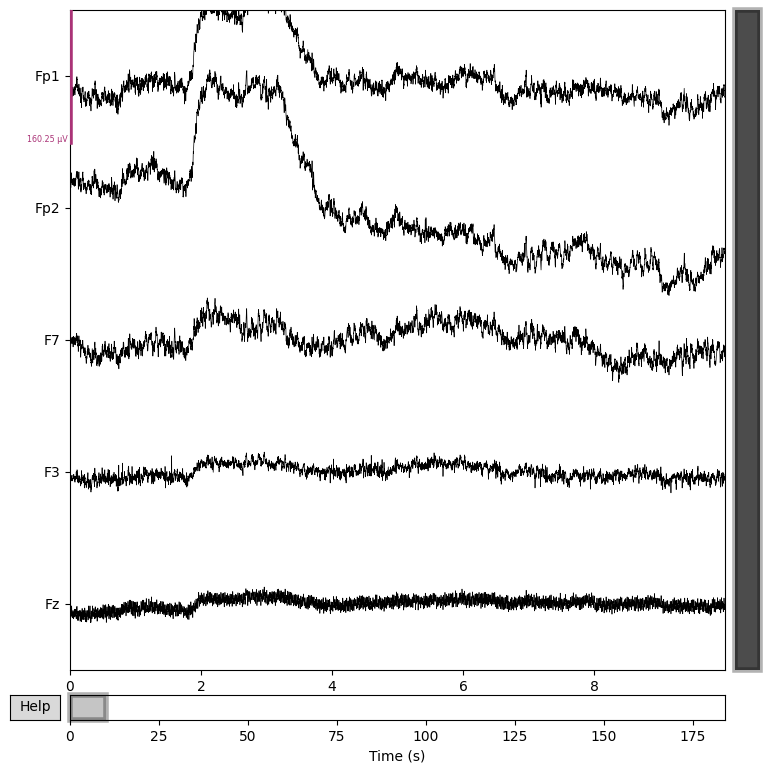

In [7]:
"""
Plot a short segment of raw EEG signal as a visual sanity check, and
save the figure for later inclusion in this project's GitHub
repository.
"""

fig = raw.copy().pick(raw.ch_names[:5]).plot(
    duration=10, n_channels=5, scalings="auto", show=False
)
fig.savefig(f"{FIGURES_DIR}/01_raw_signal_sample.png", dpi=150, bbox_inches="tight")
plt.show()

## Step 6 — Retrieve the Figure for Local Use

The raw signal plot is downloaded to the local machine for inclusion in the project repository, since files on the Colab VM's disk do not persist once the session ends.


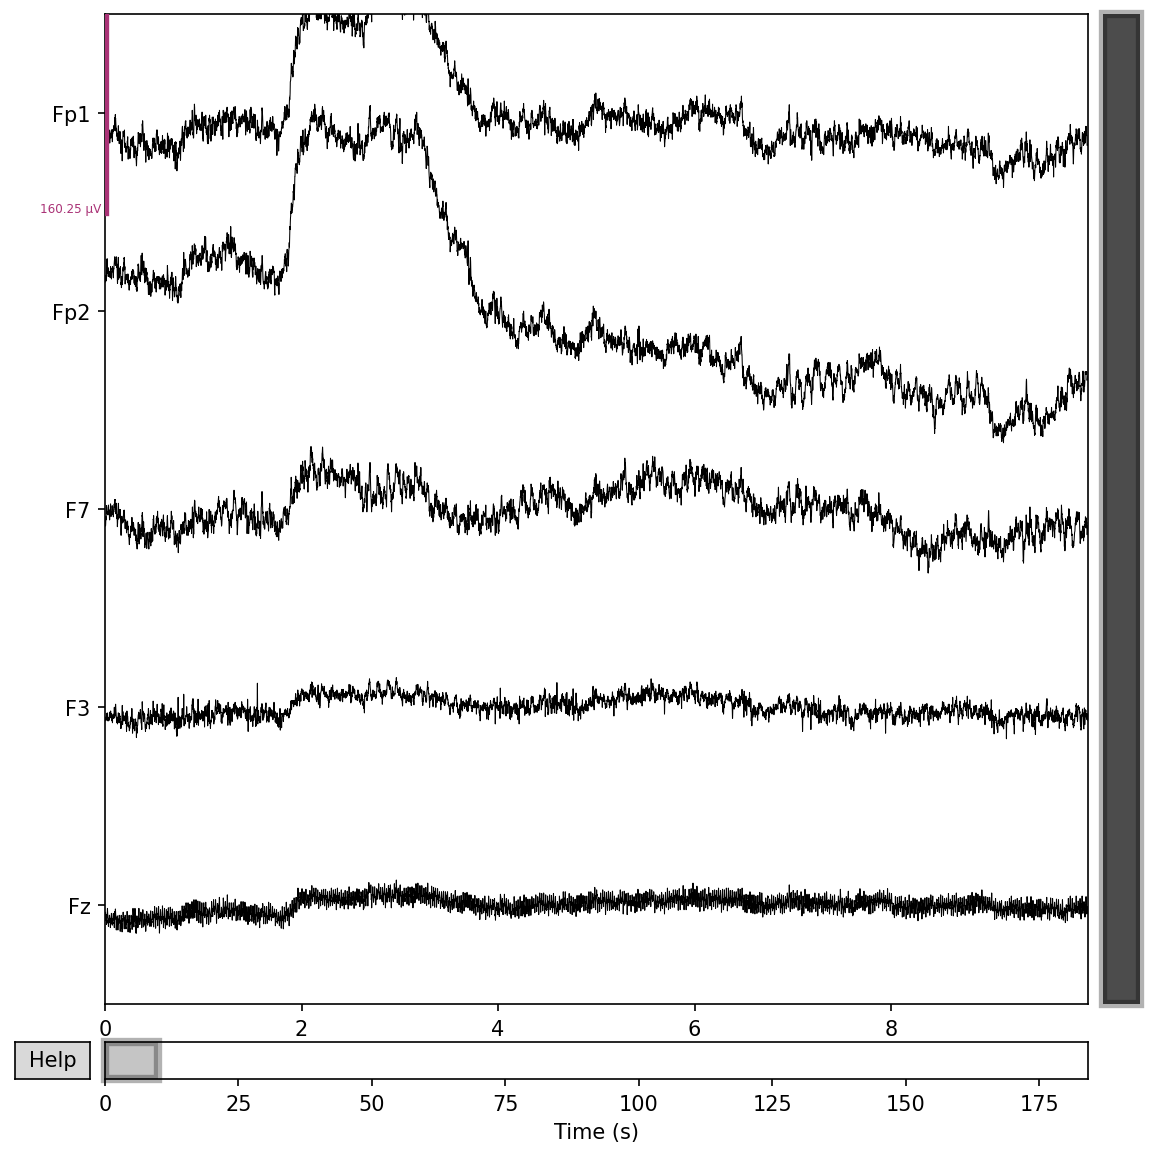

In [8]:
"""
Generate a browser download link for a file on the remote Colab VM's
disk.
"""

import base64
import mimetypes
from IPython.display import HTML

def download_link(filepath):
    filename = filepath.split("/")[-1]
    mime_type, _ = mimetypes.guess_type(filepath)
    mime_type = mime_type or "application/octet-stream"
    with open(filepath, "rb") as f:
        b64 = base64.b64encode(f.read()).decode()
    return HTML(f'<a download="{filename}" href="data:{mime_type};base64,{b64}">Download {filename}</a>')

download_link(f"{FIGURES_DIR}/01_raw_signal_sample.png")

## Step 7 — Verify Every Recording Loads Cleanly

A final pass loads `.raw` for every recording in the cohort to confirm each one reads without error before moving to preprocessing. Progress is reported periodically rather than per-recording, since this cohort has 416 members, and failures are collected rather than raised immediately so one bad recording doesn't halt the whole pass.

In [9]:
"""
Open every downloaded recording as a final verification pass,
confirming each file exists and reads without error before
preprocessing.
"""

failed_subjects = []
total = len(cohort)

for i, row in enumerate(cohort.itertuples(), start=1):
    try:
        _ = mne.io.read_raw_edf(os.path.join(RAW_DIR, row.recording), preload=False, verbose=False)
    except Exception as e:
        failed_subjects.append(row.subject)
        print(f"[{i}/{total}] FAILED - subject {row.subject}: {e}")
    if i % 25 == 0 or i == total:
        print(f"[{i}/{total}] checked, {len(failed_subjects)} failure(s) so far")

if failed_subjects:
    print(f"\n{len(failed_subjects)} subject(s) failed to load: {failed_subjects}")
else:
    print(f"\nAll {total} recordings in the cohort loaded successfully.")

[25/416] checked, 0 failure(s) so far
[50/416] checked, 0 failure(s) so far
[75/416] checked, 0 failure(s) so far
[100/416] checked, 0 failure(s) so far
[125/416] checked, 0 failure(s) so far
[150/416] checked, 0 failure(s) so far
[175/416] checked, 0 failure(s) so far
[200/416] checked, 0 failure(s) so far
[225/416] checked, 0 failure(s) so far
[250/416] checked, 0 failure(s) so far
[275/416] checked, 0 failure(s) so far
[300/416] checked, 0 failure(s) so far
[325/416] checked, 0 failure(s) so far
[350/416] checked, 0 failure(s) so far
[375/416] checked, 0 failure(s) so far
[400/416] checked, 0 failure(s) so far
[416/416] checked, 0 failure(s) so far

All 416 recordings in the cohort loaded successfully.


## Summary

The pre-task, eyes-closed, session-1 recording of every subject in the labeled cohort (416 subjects: 203 young, 213 old) was downloaded directly from OpenNeuro's public S3 bucket, using the exact file path defined in Notebook 00. A single recording was inspected in detail and confirmed to match the dataset's documented structure, and a final pass verified that every recording in the cohort loads without error.

The next notebook (`02_preprocessing.ipynb`) filters, re-references, and prepares these recordings for spectral feature extraction.